<a href="https://colab.research.google.com/github/RodrigoGutV/ciencia-de-dato-s8/blob/main/RGV_IACC_S8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [6]:
# Cargar dataset
ruta = "dataset_set_A_aguas_residuales.xlsx"
df = pd.read_excel(ruta)

print(df.head())
print(df.info())

  fecha_registro         planta  caudal_entrada_m3_d  DBO_entrada_mg_L  \
0     2025-08-17     Planta Sur                 6562               271   
1     2025-09-07     Planta Sur                 5336               322   
2     2025-07-26   Planta Norte                 5755               318   
3     2025-10-27  Planta Centro                 6840               216   
4     2025-09-06  Planta Centro                 6803               326   

   SST_entrada_mg_L  pH_entrada  energia_aeracion_kWh  lodos_generados_kg_d  \
0               324        7.12                1261.1                 440.3   
1               230        7.01                1629.3                 561.2   
2               282        6.79                1469.2                 441.6   
3               167        7.01                1764.8                 560.0   
4               200        7.55                1409.3                 654.0   

   DBO_salida_mg_L  cumplimiento_norma  
0             40.0                   0 

In [7]:
# Conversión de fecha
df['fecha_registro'] = pd.to_datetime(df['fecha_registro'])

# Validación de nulos
print(df.isnull().sum())

# Eliminación de duplicados
df = df.drop_duplicates()

fecha_registro          0
planta                  0
caudal_entrada_m3_d     0
DBO_entrada_mg_L        0
SST_entrada_mg_L        0
pH_entrada              0
energia_aeracion_kWh    0
lodos_generados_kg_d    0
DBO_salida_mg_L         0
cumplimiento_norma      0
dtype: int64


In [8]:
# Presentar eficiencia de remoción de DBO

df['eficiencia_remocion'] = (
    (df['DBO_entrada_mg_L'] - df['DBO_salida_mg_L'])
    / df['DBO_entrada_mg_L']
) * 100

# Revisar el consumo energético

df['energia_por_m3'] = (
    df['energia_aeracion_kWh']
    / df['caudal_entrada_m3_d']
)

# Índice de generación de lodos

df['indice_lodos'] = (
    df['lodos_generados_kg_d']
    / df['caudal_entrada_m3_d']
)

cumplimiento_norma
0    155
1     45
Name: count, dtype: int64
planta
Planta Centro    35.901333
Planta Norte     36.560563
Planta Sur       36.057407
Name: DBO_salida_mg_L, dtype: float64


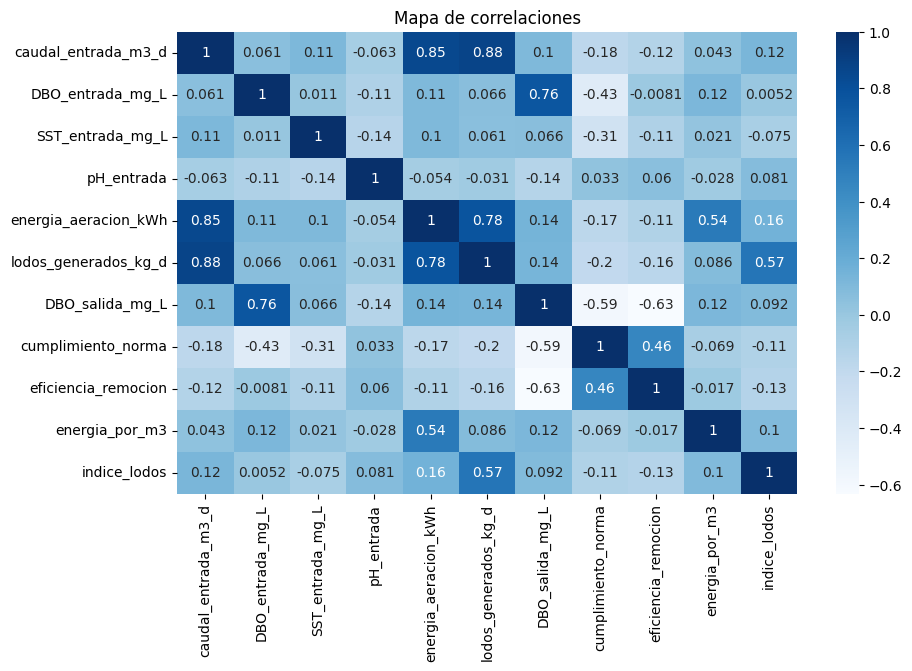

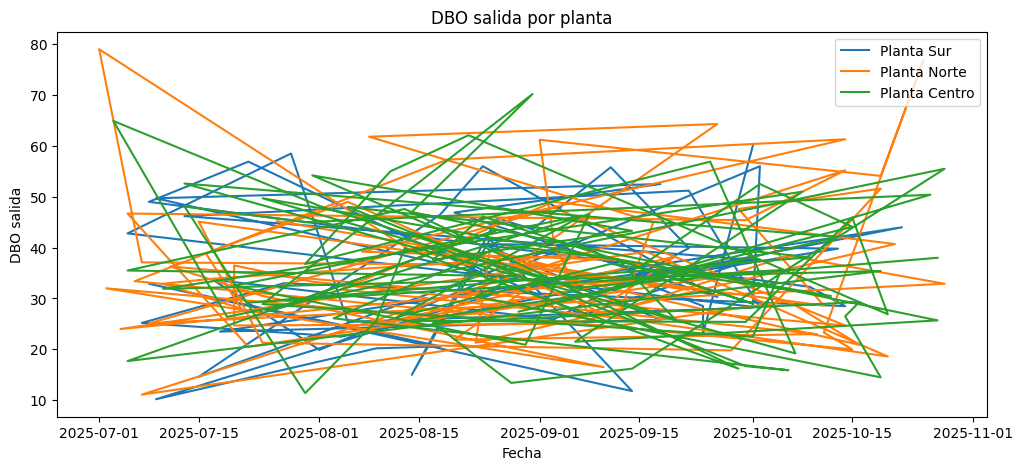

In [ ]:
cumplimiento = df['cumplimiento_norma'].value_counts()
print(cumplimiento)

promedio_dbo = df.groupby('planta')['DBO_salida_mg_L'].mean()
print(promedio_dbo)

correlacion = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,6))
sns.heatmap(correlacion, annot=True, cmap='Blues')
plt.title('Mapa de correlaciones')
plt.show()

plt.figure(figsize=(12,5))

for planta in df['planta'].unique():
    datos = df[df['planta'] == planta]
    plt.plot(datos['fecha_registro'], datos['DBO_salida_mg_L'], label=planta)

plt.title('DBO salida por planta')
plt.xlabel('Fecha')
plt.ylabel('DBO salida')
plt.legend()
plt.show()

In [10]:
# ============================================================
# DASHBOARD EXPLORATORIO - AQUALIMPIA
# ============================================================

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

# ============================================================
# KPI PRINCIPALES
# ============================================================

cumplimiento = (
    (df['cumplimiento_norma'] == 'Cumple')
    .mean() * 100
)

eficiencia_promedio = (
    df['eficiencia_remocion']
    .mean()
)

dbo_promedio = (
    df['DBO_salida_mg_L']
    .mean()
)

total_incumplimientos = (
    (df['cumplimiento_norma'] == 'Incumple')
    .sum()
)

# ============================================================
# AGRUPACIÓN EFICIENCIA
# ============================================================

promedio_eficiencia = (
    df.groupby('planta')['eficiencia_remocion']
    .mean()
    .reset_index()
)

promedio_eficiencia = promedio_eficiencia.sort_values(
    by='eficiencia_remocion',
    ascending=False
)

# ============================================================
# INCUMPLIMIENTOS
# ============================================================

incumplimientos = (
    df[df['cumplimiento_norma'] == 'Incumple']
    .groupby('planta')
    .size()
    .reset_index(name='cantidad')
)

# ============================================================
# CREACIÓN DASHBOARD
# ============================================================

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        'Evolución DBO Salida',
        'Eficiencia Promedio',
        'Incumplimientos por Planta',
        'Relación Caudal vs DBO'
    ),
    vertical_spacing=0.12
)

# ============================================================
# GRÁFICO 1
# Evolución DBO
# ============================================================

for planta in df['planta'].unique():

    datos_planta = df[df['planta'] == planta]

    fig.add_trace(

        go.Scatter(
            x=datos_planta['fecha_registro'],
            y=datos_planta['DBO_salida_mg_L'],
            mode='lines+markers',
            name=planta
        ),

        row=1,
        col=1
    )

# Línea normativa
fig.add_hline(
    y=60,
    line_dash='dash',
    line_color='red',
    annotation_text='Límite normativo',
    row=1,
    col=1
)

# ============================================================
# GRÁFICO 2
# Eficiencia promedio
# ============================================================

fig.add_trace(

    go.Bar(
        x=promedio_eficiencia['planta'],
        y=promedio_eficiencia['eficiencia_remocion'],
        text=promedio_eficiencia[
            'eficiencia_remocion'
        ].round(1),
        textposition='outside',
        name='Eficiencia'
    ),

    row=1,
    col=2
)

# Línea meta operacional
fig.add_hline(
    y=85,
    line_dash='dash',
    line_color='green',
    annotation_text='Meta 85%',
    row=1,
    col=2
)

# ============================================================
# GRÁFICO 3
# Incumplimientos
# ============================================================

fig.add_trace(

    go.Bar(
        x=incumplimientos['cantidad'],
        y=incumplimientos['planta'],
        orientation='h',
        text=incumplimientos['cantidad'],
        textposition='outside',
        name='Incumplimientos'
    ),

    row=2,
    col=1
)

# ============================================================
# GRÁFICO 4
# Scatter operacional
# ============================================================

fig.add_trace(

    go.Scatter(
        x=df['caudal_entrada_m3_d'],
        y=df['DBO_salida_mg_L'],
        mode='markers',
        marker=dict(
            size=10
        ),
        text=df['planta'],
        name='Caudal vs DBO'
    ),

    row=2,
    col=2
)

# ============================================================
# FORMATO GENERAL
# ============================================================

fig.update_layout(

    title={
        'text':
        (
            '<b>Dashboard Exploratorio '
            'AquaLimpia S. A.</b><br>'
            f'Cumplimiento: {cumplimiento:.1f}% | '
            f'Eficiencia promedio: '
            f'{eficiencia_promedio:.1f}% | '
            f'DBO promedio: {dbo_promedio:.1f} mg/L | '
            f'Incumplimientos: '
            f'{total_incumplimientos}'
        ),
        'x':0.5
    },

    height=900,

    showlegend=True,

    template='plotly_white'
)

# ============================================================
# EJES
# ============================================================

fig.update_xaxes(title_text='Fecha', row=1, col=1)
fig.update_yaxes(title_text='DBO Salida', row=1, col=1)

fig.update_xaxes(title_text='Planta', row=1, col=2)
fig.update_yaxes(title_text='Eficiencia (%)', row=1, col=2)

fig.update_xaxes(
    title_text='Cantidad Incumplimientos',
    row=2,
    col=1
)

fig.update_yaxes(
    title_text='Planta',
    row=2,
    col=1
)

fig.update_xaxes(
    title_text='Caudal Entrada',
    row=2,
    col=2
)

fig.update_yaxes(
    title_text='DBO Salida',
    row=2,
    col=2
)

# ============================================================
# MOSTRAR DASHBOARD
# ============================================================

fig.show()

In [11]:
#genera archivos de salida
operaciones = df[[
    'fecha_registro',
    'planta',
    'caudal_entrada_m3_d',
    'DBO_entrada_mg_L',
    'DBO_salida_mg_L',
    'energia_aeracion_kWh',
    'lodos_generados_kg_d'
]]

operaciones.to_excel('reporte_operaciones.xlsx', index=False)

ambiental = df[[
    'fecha_registro',
    'planta',
    'DBO_salida_mg_L',
    'cumplimiento_norma'
]]

ambiental.to_excel('reporte_gestion_ambiental.xlsx', index=False)